# TP1_Data_Analysis_Notebook

Here we consider recordings of action potentials and extracellular local field potential (LFP) obtained from the primary somatosensory cortex from the rat. Tactile stimulations were applied on the tip of the forehand digit (2, 3, 4 and 5) while extracellular recording electrodes were placed in layer 4 of the Forehand representation of the primary somatosensory cortex.

Each file contains the data for 900 stimuli, with the following variables:
- DataUnit: dictionary of all variables
- LFP: analog local-field potential signal Sampling rate = 1000 Hz
- Unit: list of 0 or 1 (1 corresponding to a spike) for all time points Sampling rate = 1000 Hz
- SpikeTiming: list of spike times 
- StimCond: array with column 0 containing the time stamp for each stimulus, and column 1 the stimulus type 

    (**note that the stimulus is applied 50ms after that time stamp**)
- WaveForm: waveform of the recorded spike

The aim of this notebook is to learn how to analyse electrophysiological data, performing some basic analyses and visualizations.


In [49]:
import numpy as np
import matplotlib.pyplot as plt
import os   

# if last word in path == scripts then go back one directory
if os.getcwd().endswith('scripts'):
    os.chdir('..')
os.getcwd()


'd:\\DATA\\Projets\\EMN_IntroProgram_NC'

In [50]:

# data is a dictionary with keys: 'LFP', 'Unit', 'StimCond'
# here, we load the data from a .npy file and extract the relevant components for analysis.
data = np.load("data/Cell_3.npy", allow_pickle=True)
data = data.item()
lfp=data['LFP']
unit=data['Unit']
StimCond=data['StimCond']
data.keys()



dict_keys(['LFP', 'Unit', 'SpikeTiming', 'StimCond', 'Waveform'])

# *LFP  (local field potential)*

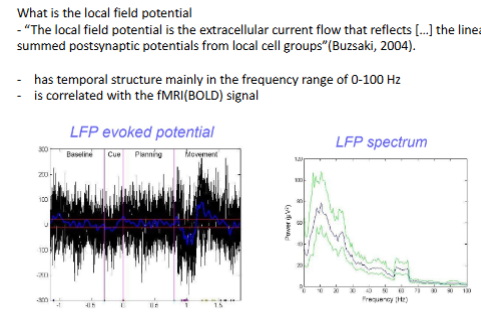

Text(0.5, 0, 'Time (samples)')

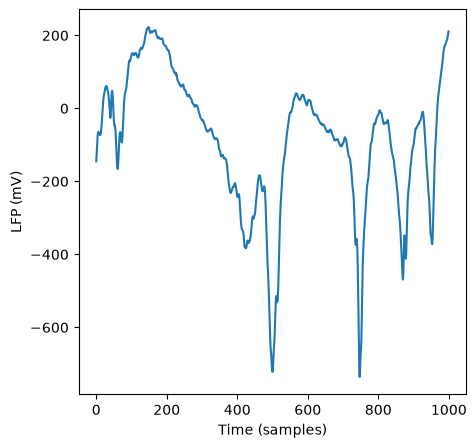

In [51]:
fig,ax=plt.subplots(1,1,figsize=(5,5))
plt.plot(lfp[17000:18000])
plt.ylabel('LFP (mV)')
plt.xlabel('Time (samples)')

For today : 
- realigning LFP on stimulus onsets
- Raster plot
- PSTH
- tuning curves


Text(0.5, 1.0, 'LFP aligned to stimulus onset')

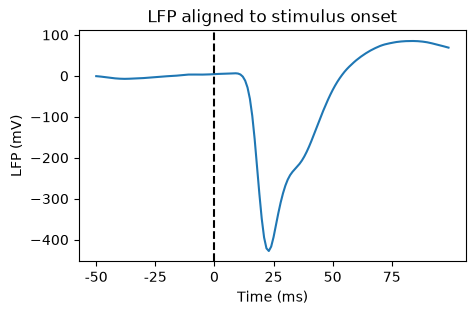

In [52]:
# here we realign the LFP data to the stimulus onset, which is indicated by the StimCond array. We extract a window of LFP data around each stimulus onset and store it in a list for further analysis.
# here we plot the average LFP response across all stimulus presentations, with a vertical dashed line indicating the time of stimulus onset.

lfp_aligned=[]
before=-50
after=100

for i in range(len(StimCond)):
    lfp_aligned.append(lfp[StimCond[i,0]+50+before:StimCond[i,0]+50+after])
    
plt.figure(figsize=(5,3))
plt.plot(np.mean(lfp_aligned,axis=0))
plt.axvline(x=50,color='k',linestyle='--')
plt.ylabel('LFP (mV)')
plt.xlabel('Time (ms)')
plt.xticks(np.arange(0,150,25),np.arange(before,after,25))
plt.xlabel('Time (ms)')
plt.title('LFP aligned to stimulus onset')


In [53]:
len(unit)

1007683

# *Single Unit (SU)*
Single Unit (SU) data is a binary array where 1 indicates a spike and 0 indicates no spike. We can realign the SU data to the stimulus onset in a similar way as we did for the LFP data, and then plot the aligned SU data as a raster plot.

In [57]:
# here we realign the unit data to the stimulus onset, which is indicated by the StimCond array. We extract a window of unit data around each stimulus onset and store it in a list for further analysis.
unit_aligned=[]

for i in range(len(StimCond)):
    unit_aligned.append(unit[StimCond[i,0]+50+before:StimCond[i,0]+50+after])
    


# Raster plot

A raster plot in neuroscience is a graphical chart that shows when individual neurons fire action potentials (spikes) over time.

Key Components

• X-axis: Represents time (e.g., seconds or milliseconds).
• Y-axis: Represents different neurons (or different trials of the same neuron).
• Markers: Each vertical tick mark, dot, or line corresponds to a single spike emitted at that exact moment

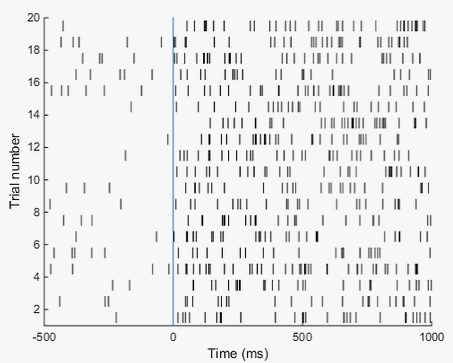

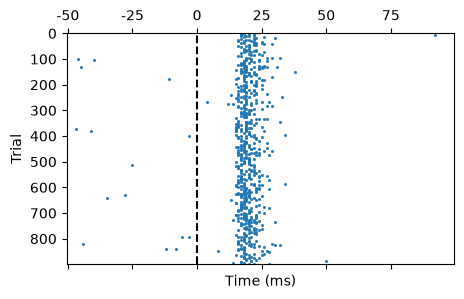

In [63]:
plt.figure(figsize=(5,3))
plt.spy(unit_aligned,aspect='auto',markersize=1)
plt.xlabel('Time (ms)')
plt.ylabel('Trial')
plt.xticks(np.arange(0,150,25),np.arange(before,after,25))
plt.axvline(x=50,color='k',linestyle='--')
plt.show()

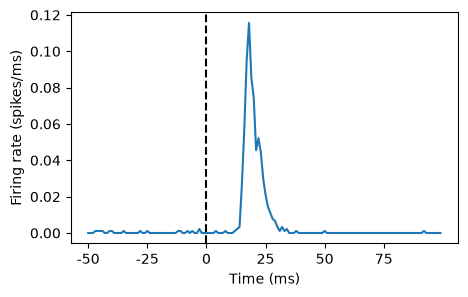

In [64]:
plt.figure(figsize=(5,3))
plt.plot(np.mean(unit_aligned,axis=0))
plt.axvline(x=50,color='k',linestyle='--')
plt.ylabel('Firing rate (spikes/ms)')
plt.xlabel('Time (ms)')
plt.xticks(np.arange(0,150,25),np.arange(before,after,25))
plt.show()